## Goal of the data analysis

## Target Audience

## Modules used for this analysis

In [2]:
import pandas as pd
import seaborn as sns
import geopandas as geo
import matplotlib.pyplot as plt

## Phase 1: Get the data

### About Earthquakes Data 

#### URL for the data and its document
Data URL: https://www.kaggle.com/datasets/alessandrolobello/the-ultimate-earthquake-dataset-from-1990-2023<br>
Document URL: https://earthquake.usgs.gov/data/comcat/index.php#1

|Column|Description|
|------|-----------|
|time | Time when the event occurred. Times are reported in milliseconds since the epoch( 1970-01-01T00:00:00.000Z)|
|place | Textual description of named geographic region near to the event.|
|status | Indicates whether the event has been reviewed by a human. Automatic events are directly posted by automatic processing systems. |
|tsunami | This flag is set to "1" for large events in oceanic regions and "0" otherwise.|
|significance | A number describing how significant the event is. Determined on various factors, including: magnitude, maximum MMI, felt reports, and estimated impact.|
|data_type | Type of seismic event |
|magnitudo | The magnitude for the event.| 
|state | Country or state names |
|longitude | Decimal degrees longitude. Negative values for western longitudes.|
|latitude | Decimal degrees latitude. Negative values for southern latitudes. |
|depth | Depth of the event in kilometers.|
|date | Date and time of the event|

#### My Experience on Getting the data

#### Load the csv file into a DataFrame

In [ ]:
df = pd.read_csv('data/Earthquakes-1990-2023.csv', encoding='unicode_escape')

#### Check the first and last 5 rows to confirm all the rows have been loaded 

In [4]:
df.head()

,time,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date
0,631153353990,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00
1,631153491210,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00
2,631154083450,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00
3,631155512130,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00
4,631155824490,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00


In [5]:
df.tail()

,time,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date
3445746,1690626851941,"5 km NW of Chikusei, Japan",reviewed,0,326,earthquake,4.60,Japan,139.940200,36.350700,83.039,2023-07-29 10:34:11.941000+00:00
3445747,1690626975715,"Kodiak Island region, Alaska",automatic,0,44,earthquake,1.70,Alaska,-153.729900,57.790100,24.400,2023-07-29 10:36:15.715000+00:00
3445748,1690627215940,"12 km W of Alberto Oviedo Mota, B.C., MX",automatic,0,90,earthquake,2.42,B.C.,-115.296833,32.233167,1.770,2023-07-29 10:40:15.940000+00:00
3445749,1690628146040,"7 km W of Cobb, CA",automatic,0,16,earthquake,1.03,California,-122.800499,38.827499,1.720,2023-07-29 10:55:46.040000+00:00
3445750,1690628937884,"35 km W of Karluk, Alaska",automatic,0,12,earthquake,0.90,Alaska,-155.051000,57.564800,250.000,2023-07-29 11:08:57.884000+00:00


#### Check the shape of the DataFrame

In [6]:
original_shape = df.shape

In [7]:
original_shape

(3445751, 12)

#### Saves the original DataFrame to a pickle file in case I make a mistake while cleaning the data

In [8]:
df.to_pickle('df_raw.pkl')

## Phase 2: Clean the data

### Step 1. Examine the data

In [9]:
df.info(verbose=True, memory_usage='deep', show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3445751 entries, 0 to 3445750
Data columns (total 12 columns):
 #   Column        Non-Null Count    Dtype  
---  ------        --------------    -----  
 0   time          3445751 non-null  int64  
 1   place         3445751 non-null  object 
 2   status        3445751 non-null  object 
 3   tsunami       3445751 non-null  int64  
 4   significance  3445751 non-null  int64  
 5   data_type     3445751 non-null  object 
 6   magnitudo     3445751 non-null  float64
 7   state         3445751 non-null  object 
 8   longitude     3445751 non-null  float64
 9   latitude      3445751 non-null  float64
 10  depth         3445751 non-null  float64
 11  date          3445751 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 1.3 GB


In [10]:
df.nunique(dropna=False)

time            3428775
place            531130
status                6
tsunami               2
significance       1170
data_type            25
magnitudo           933
state               858
longitude        733599
latitude         518295
depth             78386
date            3428775
dtype: int64

In [11]:
df.apply(pd.unique)

time            [631153353990, 631153491210, 631154083450, 631...
place           [12 km NNW of Meadow Lakes, Alaska, 14 km S of...
status          [reviewed, automatic, AUTOMATIC, REVIEWED, MAN...
tsunami                                                    [0, 1]
significance    [96, 31, 19, 15, 134, 118, 20, 11, 39, 74, 64,...
data_type       [earthquake, quarry blast, explosion, other ev...
magnitudo       [2.5, 1.41, 1.11, 0.98, 2.95, 2.77, 1.13, 0.83...
state           [ Alaska,  Hawaii,  California, California,  W...
longitude       [-149.6692, -155.2123333, -122.8061667, -118.8...
latitude        [61.7302, 19.3176667, 38.821, 37.6643333, 34.5...
depth           [30.1, 6.585, 3.22, -0.584, 16.122, 16.342, -1...
date            [1990-01-01 00:22:33.990000+00:00, 1990-01-01 ...
dtype: object

In [12]:
df.describe()

,time,tsunami,significance,magnitudo,longitude,latitude,depth
count,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06,3.445751e+06
mean,1.247124e+12,4.434447e-04,7.400973e+01,1.774076e+00,-1.012876e+02,3.746483e+01,2.285387e+01
std,2.976292e+11,2.105346e-02,1.016364e+02,1.291055e+00,7.697416e+01,2.041577e+01,5.484938e+01
min,6.311534e+11,0.000000e+00,0.000000e+00,-9.990000e+00,-1.799997e+02,-8.442200e+01,-1.000000e+01
25%,1.024401e+12,0.000000e+00,1.300000e+01,9.100000e-01,-1.464274e+02,3.406400e+01,3.120000e+00
50%,1.282338e+12,0.000000e+00,3.300000e+01,1.460000e+00,-1.189538e+02,3.793567e+01,7.700000e+00
75%,1.508701e+12,0.000000e+00,8.100000e+01,2.300000e+00,-1.159277e+02,4.784800e+01,1.612000e+01
max,1.690629e+12,1.000000e+00,2.910000e+03,9.100000e+00,1.800000e+02,8.738600e+01,7.358000e+02


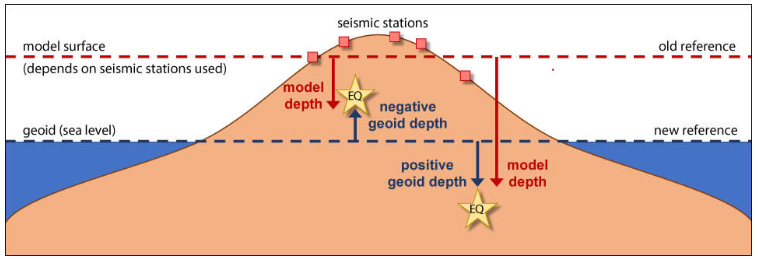

<font color='yellow'>=>Both negative magnitudes and negative depths are reasonable values.</font>

#### Summary of findings

### Step 2. Drop unneccesary rows and columns

#### (1) Make the values consistent in the 'status' column 

Current 'status' values => There are 6 of them

In [13]:
df.apply(pd.unique)

time            [631153353990, 631153491210, 631154083450, 631...
place           [12 km NNW of Meadow Lakes, Alaska, 14 km S of...
status          [reviewed, automatic, AUTOMATIC, REVIEWED, MAN...
tsunami                                                    [0, 1]
significance    [96, 31, 19, 15, 134, 118, 20, 11, 39, 74, 64,...
data_type       [earthquake, quarry blast, explosion, other ev...
magnitudo       [2.5, 1.41, 1.11, 0.98, 2.95, 2.77, 1.13, 0.83...
state           [ Alaska,  Hawaii,  California, California,  W...
longitude       [-149.6692, -155.2123333, -122.8061667, -118.8...
latitude        [61.7302, 19.3176667, 38.821, 37.6643333, 34.5...
depth           [30.1, 6.585, 3.22, -0.584, 16.122, 16.342, -1...
date            [1990-01-01 00:22:33.990000+00:00, 1990-01-01 ...
dtype: object

Change all strings to lower case

In [14]:
df['status'] = df['status'].str.lower()

Confirm the change 

In [15]:
df.apply(pd.unique)

time            [631153353990, 631153491210, 631154083450, 631...
place           [12 km NNW of Meadow Lakes, Alaska, 14 km S of...
status                              [reviewed, automatic, manual]
tsunami                                                    [0, 1]
significance    [96, 31, 19, 15, 134, 118, 20, 11, 39, 74, 64,...
data_type       [earthquake, quarry blast, explosion, other ev...
magnitudo       [2.5, 1.41, 1.11, 0.98, 2.95, 2.77, 1.13, 0.83...
state           [ Alaska,  Hawaii,  California, California,  W...
longitude       [-149.6692, -155.2123333, -122.8061667, -118.8...
latitude        [61.7302, 19.3176667, 38.821, 37.6643333, 34.5...
depth           [30.1, 6.585, 3.22, -0.584, 16.122, 16.342, -1...
date            [1990-01-01 00:22:33.990000+00:00, 1990-01-01 ...
dtype: object

<font color='yellow'>=> the 'status' column now has only 3 statuses</font>

#### (2) Make the values consistent in the 'state' column

In [16]:
# show the counts for each category
df.state.value_counts().head(30)

state
 California             866675
 Alaska                 777881
California              491689
 Nevada                 174065
 Hawaii                 125336
 Washington              80483
 Utah                    55471
 Montana                 53426
 Indonesia               48502
 Puerto Rico             46275
 Chile                   37171
 Greece                  30423
 B.C.                    30000
 Japan                   28908
 Oklahoma                25132
 Papua New Guinea        23030
 Italy                   18632
 Philippines             17822
 Oregon                  17650
 Mexico                  16573
 Turkey                  15929
 Russia                  15529
 Wyoming                 15170
 Tonga                   12819
 Idaho                   12645
 Aleutian Islands        12504
 New Zealand             12298
 Canada                  11575
 France                  11259
 U.S. Virgin Islands     11243
Name: count, dtype: int64

<font color='yellow'>I noticed that 'California' and ' California' are in the 'state' column. </font>

In [17]:
df.query('state == " Washington"').shape

(80483, 12)

In [18]:
df.query('state == "Washington"').shape

(1869, 12)

In [19]:
df.state.nunique()

858

##### Strip the leading white space(s) in the 'state' column values 

In [20]:
# strip the beginning space(s) from the values of the 'state' column
df['state'] = df['state'].apply(lambda x: x.lstrip())

In [21]:
df.state.nunique()

765

In [22]:
df.state.value_counts().head(30)

state
California             1358364
Alaska                  777881
Nevada                  177078
Hawaii                  125336
Washington               82352
Utah                     57203
Montana                  53426
Indonesia                48502
Puerto Rico              46275
Chile                    37171
Greece                   30648
B.C.                     30000
Japan                    28908
Oklahoma                 25814
Papua New Guinea         23030
Italy                    18632
Oregon                   17972
Philippines              17822
Mexico                   16573
Wyoming                  16555
Turkey                   15929
Russia                   15529
Tonga                    13056
Idaho                    12645
Aleutian Islands         12504
New Zealand              12298
Canada                   11575
France                   11439
U.S. Virgin Islands      11243
Vanuatu                  10046
Name: count, dtype: int64

#### (3) Drop duplicates

##### Find the duplicates

In [23]:
df[df.duplicated(keep=False)]

,time,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date
9213,636249654650,"3 km E of Mammoth Lakes, California",reviewed,0,42,earthquake,1.66,California,-118.933667,37.6470,3.816,1990-03-01 00:00:54.650000+00:00
9214,636249654650,"3 km E of Mammoth Lakes, California",reviewed,0,42,earthquake,1.66,California,-118.933667,37.6470,3.816,1990-03-01 00:00:54.650000+00:00
9215,636249667890,"4km N of Claremont, CA",reviewed,0,70,earthquake,2.13,California,-117.717000,34.1330,4.275,1990-03-01 00:01:07.890000+00:00
9216,636249667890,"4km N of Claremont, CA",reviewed,0,70,earthquake,2.13,California,-117.717000,34.1330,4.275,1990-03-01 00:01:07.890000+00:00
9217,636249694400,"4km N of Claremont, CA",reviewed,0,62,earthquake,2.00,California,-117.717000,34.1330,4.275,1990-03-01 00:01:34.400000+00:00
...,...,...,...,...,...,...,...,...,...,...,...,...
3386780,1677800938538,"49 km N of Petersville, Alaska",reviewed,0,35,earthquake,1.50,Alaska,-150.759600,62.9424,109.700,2023-03-02 23:48:58.538000+00:00
3386781,1677801044380,"83 km NNW of Karluk, Alaska",reviewed,0,0,earthquake,0.04,Alaska,-155.069167,58.2460,4.900,2023-03-02 23:50:44.380000+00:00
3386782,1677801044380,"83 km NNW of Karluk, Alaska",reviewed,0,0,earthquake,0.04,Alaska,-155.069167,58.2460,4.900,2023-03-02 23:50:44.380000+00:00
3386783,1677801390104,"49 km W of Port-Olry, Vanuatu",reviewed,0,298,earthquake,4.40,Vanuatu,166.615000,-15.0880,10.000,2023-03-02 23:56:30.104000+00:00


##### Drop the duplicate rows

In [24]:
df = df.drop_duplicates(keep='first')

Check the new shape

In [25]:
df.shape

(3428881, 12)

#### (4) Drop non-earthquake rows

In [26]:
df.data_type.unique()

array(['earthquake', 'quarry blast', 'explosion', 'other event',
       'nuclear explosion', 'rock burst', 'ice quake',
       'chemical explosion', 'sonic boom', 'mine collapse', 'rockslide',
       'Rock Slide', 'accidental explosion', 'landslide', 'quarry',
       'mining explosion', 'acoustic noise', 'not reported',
       'experimental explosion', 'collapse', 'meteorite',
       'induced or triggered event', 'volcanic eruption', 'Ice Quake',
       'snow avalanche'], dtype=object)

Only keep the 'earthquake' rows

In [27]:
df = df.query('data_type == "earthquake"')

In [28]:
df.shape

(3345359, 12)

In [29]:
df.to_pickle('df_earthquake.pkl')

#### (5) Drop unnecessary columns 

<font color='violet'>About 'time' column</font><br>The description of time on the document says: "Time when the event occurred. Times are reported in milliseconds since the epoch ( 1970-01-01T00:00:00.000Z), and do not include leap seconds."<br> As we already have 'date' column to show the actual date and time of the event, I drop this 'time' column.

In [30]:
df = df.drop(columns=['time'])

Confirm the change

In [31]:
df.head()

,place,status,tsunami,significance,data_type,magnitudo,state,longitude,latitude,depth,date
0,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00
1,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00
2,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00
3,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00
4,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00


#### (6) Rename the 'magnitudo' column to 'magnitude'

In [32]:
df = df.rename(columns={'magnitudo':'magnitude'})

Confirm the change

In [33]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3345359 entries, 0 to 3445750
Data columns (total 11 columns):
 #   Column        Dtype  
---  ------        -----  
 0   place         object 
 1   status        object 
 2   tsunami       int64  
 3   significance  int64  
 4   data_type     object 
 5   magnitude     float64
 6   state         object 
 7   longitude     float64
 8   latitude      float64
 9   depth         float64
 10  date          object 
dtypes: float64(4), int64(2), object(5)
memory usage: 306.3+ MB


### Step 3. Handle invalid or missing values

#### Check missing values

In [34]:
df.isna().sum()

place           0
status          0
tsunami         0
significance    0
data_type       0
magnitude       0
state           0
longitude       0
latitude        0
depth           0
date            0
dtype: int64

#### Checking outliers

##### Outliers in 'significance'

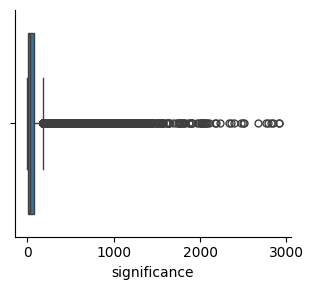

In [35]:
sns.catplot(data=df, kind='box', x='significance', height = 3)

<font color='yellow'>I do not think any values should be removed, seeing that high significance values still look clustered.</font>

##### Outliers in 'magnitude'

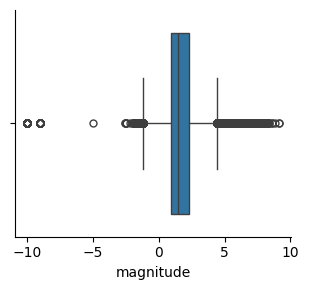

In [36]:
sns.catplot(data=df, kind='box', x='magnitude', height = 3)

In [37]:
negative_df = df.query('magnitude <-5')
negative_df.shape

(639, 11)

<font color='yellow'>Since negative magnitudes are reasonable and there are enough of them in the datasets, I would leave them as-is.</font>

##### Outliers in 'depth'

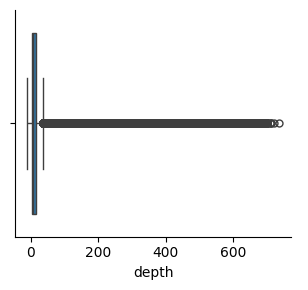

In [38]:
sns.catplot(data=df, kind='box', x='depth', height = 3)

<font color='yellow'>No obvious outliers.</font>

##### Saves the current DataFrame just in case

In [39]:
df.to_pickle('df_cleaned.pkl')

### Step 4. Convert the data types

#### Check the data types

In [40]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3345359 entries, 0 to 3445750
Data columns (total 11 columns):
 #   Column        Dtype  
---  ------        -----  
 0   place         object 
 1   status        object 
 2   tsunami       int64  
 3   significance  int64  
 4   data_type     object 
 5   magnitude     float64
 6   state         object 
 7   longitude     float64
 8   latitude      float64
 9   depth         float64
 10  date          object 
dtypes: float64(4), int64(2), object(5)
memory usage: 306.3+ MB


<font color='yellow'>Caused the ValueError</font>
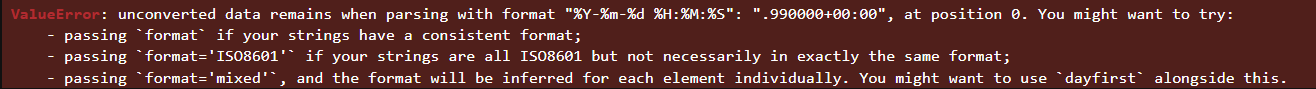

It looks like the format of 'date' values are the problem.

#### Check the format of the 'date' column value

In [41]:
# first value in the 'date' column
df['date'].iloc[0]

'1990-01-01 00:22:33.990000+00:00'

<font color='yellow'>=> Complicated format. There can be other formats included in the 'date' column as well</font>

## Phase 3: Prepare the data

#### (1) Create a  new column named 'date_and_time'

Recall the current 'date' format : '1990-01-01 00:22:33.990000+00:00'

Check how many 'date' values contain '+'

In [42]:
df['date'].str.contains('+', regex=False).sum()

3345359

In [43]:
df.shape # Check how many rows are in the current df

(3345359, 11)

Checkhow many 'date' values contain '.'

In [44]:
df['date'].str.contains('.', regex=False).sum()

3299315

##### Remove the string on and after '+' 

In [45]:
# Method to remove a string starting from the specified character 
def clean_date(row, char):
    date_str = row
    # Finds the index of the provided char
    # If not exists, -1 is returned
    index = row.find(char)  
    # If found, extract the string from the beginning to the one character before the found index
    if index != -1:
        newRow = row[0:index]
    #If not found, the original string is assigned to newRow
    else:
        newRow = date_str
    # Return the new string
    return newRow

Create a 'date_and_time' column by filling it with 'date' values where the '+' and the string after that has been removed. 

In [46]:
df['date_and_time'] = df['date'].apply(lambda row: clean_date(row, '+'))

Confirm the change

In [47]:
df['date_and_time'].str.contains('+', regex=False).sum()

0

In [48]:
df.head()

,place,status,tsunami,significance,data_type,magnitude,state,longitude,latitude,depth,date,date_and_time
0,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00,1990-01-01 00:22:33.990000
1,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00,1990-01-01 00:24:51.210000
2,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00,1990-01-01 00:34:43.450000
3,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00,1990-01-01 00:58:32.130000
4,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00,1990-01-01 01:03:44.490000


##### Remove the string on and after '.' 

In [49]:
df['date_and_time'] = df['date_and_time'].apply(lambda row: clean_date(row, '.'))

Confirm the change

In [50]:
df['date_and_time'].str.contains('.', regex=False).sum()

0

#### (2) Convert the 'date_and_time' column to datetime objects

In [51]:
df['date_and_time'] = df['date_and_time'].apply(pd.to_datetime, format ='%Y-%m-%d %H:%M:%S')

<font color ='yellow'>No more error, but it took a long time, about 3 minutes.</font>

Confirm the change

In [52]:
df.info(verbose=True, memory_usage='deep', show_counts=True)

<class 'pandas.core.frame.DataFrame'>
Index: 3345359 entries, 0 to 3445750
Data columns (total 12 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   place          3345359 non-null  object        
 1   status         3345359 non-null  object        
 2   tsunami        3345359 non-null  int64         
 3   significance   3345359 non-null  int64         
 4   data_type      3345359 non-null  object        
 5   magnitude      3345359 non-null  float64       
 6   state          3345359 non-null  object        
 7   longitude      3345359 non-null  float64       
 8   latitude       3345359 non-null  float64       
 9   depth          3345359 non-null  float64       
 10  date           3345359 non-null  object        
 11  date_and_time  3345359 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage: 1.2 GB


#### (3) Add 'year' column derived from 'date_and_time' column

In [53]:
df['year'] = df['date_and_time'].dt.year

Confirm the change

In [54]:
df.head()

,place,status,tsunami,significance,data_type,magnitude,state,longitude,latitude,depth,date,date_and_time,year
0,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00,1990-01-01 00:22:33,1990
1,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00,1990-01-01 00:24:51,1990
2,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00,1990-01-01 00:34:43,1990
3,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00,1990-01-01 00:58:32,1990
4,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00,1990-01-01 01:03:44,1990


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3345359 entries, 0 to 3445750
Data columns (total 13 columns):
 #   Column         Dtype         
---  ------         -----         
 0   place          object        
 1   status         object        
 2   tsunami        int64         
 3   significance   int64         
 4   data_type      object        
 5   magnitude      float64       
 6   state          object        
 7   longitude      float64       
 8   latitude       float64       
 9   depth          float64       
 10  date           object        
 11  date_and_time  datetime64[ns]
 12  year           int32         
dtypes: datetime64[ns](1), float64(4), int32(1), int64(2), object(5)
memory usage: 344.6+ MB


#### (4) Add 'mag_category' column to categorize magnitude values

##### Information about Earthquake Magnitude Scale 
(source: https://www.mtu.edu/geo/community/seismology/learn/earthquake-measure/magnitude/)

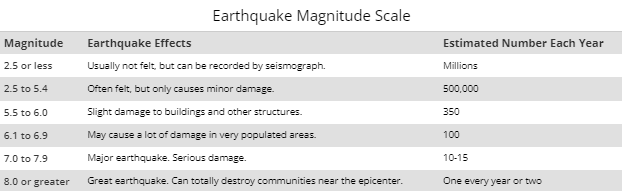

In [56]:
# Creates bins and the corresponding labels based on the above table
bins = [0, 2.5, 5.5, 6.1, 7.0, 8.0, float('inf')]
mag_labels = ['2.5 or less', '2.5 to 5.4', '5.5 to 6.0', '6.1 to 6.9', '7.0 to 7.9', '8.0 and above']

In [57]:
# Using the pandas cut() method, bins the data
# right is False, meaning the right value exclusive
df['mag_category'] = pd.cut(df['magnitude'], bins=bins, labels=mag_labels, right=False) 

In [58]:
df.head()

,place,status,tsunami,significance,data_type,magnitude,state,longitude,latitude,depth,date,date_and_time,year,mag_category
0,"12 km NNW of Meadow Lakes, Alaska",reviewed,0,96,earthquake,2.50,Alaska,-149.669200,61.730200,30.100,1990-01-01 00:22:33.990000+00:00,1990-01-01 00:22:33,1990,2.5 to 5.4
1,"14 km S of Volcano, Hawaii",reviewed,0,31,earthquake,1.41,Hawaii,-155.212333,19.317667,6.585,1990-01-01 00:24:51.210000+00:00,1990-01-01 00:24:51,1990,2.5 or less
2,"7 km W of Cobb, California",reviewed,0,19,earthquake,1.11,California,-122.806167,38.821000,3.220,1990-01-01 00:34:43.450000+00:00,1990-01-01 00:34:43,1990,2.5 or less
3,"11 km E of Mammoth Lakes, California",reviewed,0,15,earthquake,0.98,California,-118.846333,37.664333,-0.584,1990-01-01 00:58:32.130000+00:00,1990-01-01 00:58:32,1990,2.5 or less
4,"16km N of Fillmore, CA",reviewed,0,134,earthquake,2.95,California,-118.934000,34.546000,16.122,1990-01-01 01:03:44.490000+00:00,1990-01-01 01:03:44,1990,2.5 to 5.4


Saves the data to a pickle file

In [59]:
df.to_pickle('df_prepared.pkl')

## Phase 4: Analyze the Data

### Q1. What is the distribution of earthquake magnitudes between 1990 and 2023?

#### Create a table of magnitudes and their counts

In [60]:
# Group by the 'magnitude' column and count the occurrences
magnitude_distribution = df['magnitude'].value_counts().sort_index()

# Convert to a DataFrame for better display
magnitude_distribution_df = magnitude_distribution.reset_index()
magnitude_distribution_df.columns = ['magnitude', 'count']

# Display the table
magnitude_distribution_df.set_index('magnitude').T

magnitude,-9.99,-9.00,-5.00,-2.60,-2.50,-2.20,-2.00,-1.90,-1.82,-1.80,...,8.00,8.09,8.10,8.16,8.20,8.30,8.40,8.60,8.80,9.10
count,610,29,1,2,4,1,4,5,1,6,...,7,1,7,1,6,4,2,2,1,2


<font color='yellow'>It's hard to see the distribution from the table</font>

#### Visualization of the Distribution

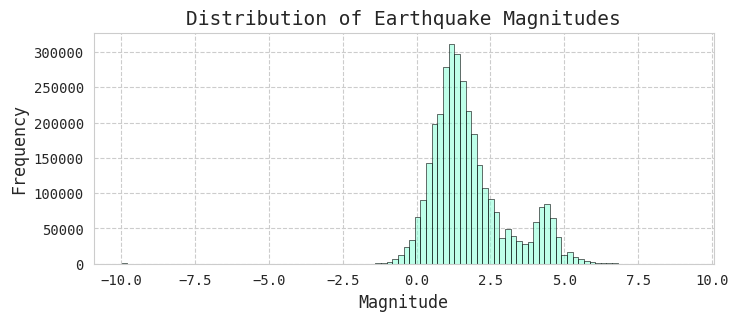

In [61]:
# Set the style 
sns.set_style('whitegrid', {"grid.linestyle": "--", 'font.family': ["monospace"]})

# Create the plot area
plt.figure(figsize=(8, 3))

# Plot the magnitude data as a histogram 
ax = sns.histplot(df['magnitude'], bins=100, color='aquamarine', edgecolor='black', alpha=0.5)

# Customize the plot
ax.set_xlabel('Magnitude', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Earthquake Magnitudes', fontsize=14)
plt.show()

#### <font color='yellow'>Answer to Q1: The plot shows that the most common magnitude is around 1.25. The frequencies of the magnitude being less than 0 or greater than 5 are quite small.</font>

### Q2. Is there an increasing trend in the number of earthquakes between 1990 and 2023?

### Create a table

In [62]:
# DataFrame to count earthquakes per year for each magnitude category
category_counts = df.groupby(['year', 'mag_category'], observed=False).size().reset_index(name='count')

In [63]:
# Using pivot() we can see the counts of each magnitude category per year
pivoted_category_counts = category_counts.pivot(index = 'year', columns='mag_category', values='count')

In [64]:
pivoted_category_counts.head()

mag_category,2.5 or less,2.5 to 5.4,5.5 to 6.0,6.1 to 6.9,7.0 to 7.9,8.0 and above
year,,,,,,
1990,38375,11362,395,99,18,0
1991,35807,11982,313,89,17,0
1992,70907,19014,384,122,13,0
1993,51796,15579,341,102,12,0
1994,51295,16189,368,110,11,2


<font color='yellow'>It's hard to see the distribution from the table due to the length</font>

### Plot the Data

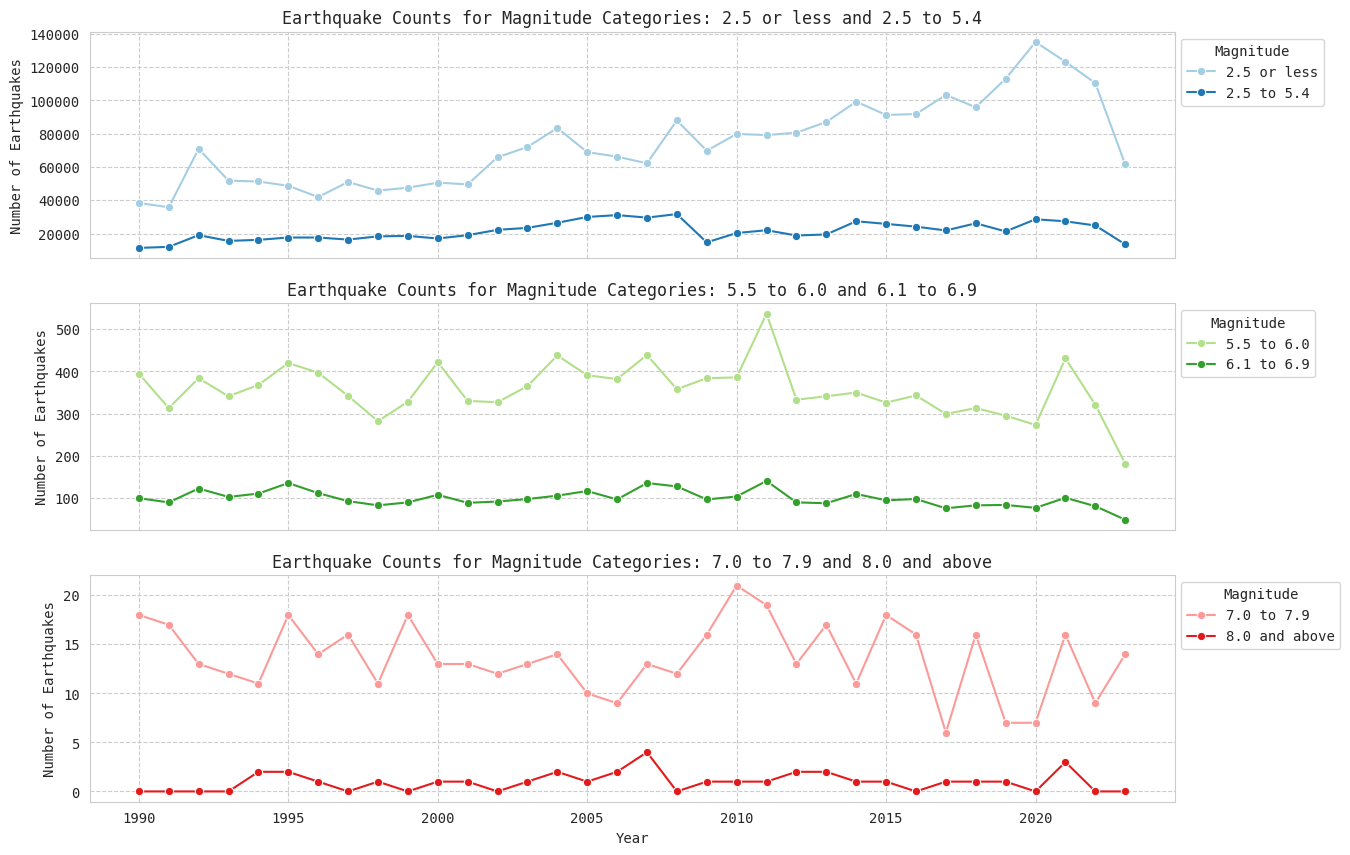

In [65]:
# DataFrame to count earthquakes per year for each magnitude category
category_counts = df.groupby(['year', 'mag_category'], observed=False).size().reset_index(name='count')

# Define pairs of categories to plot together
category_pairs = [
    ('2.5 or less', '2.5 to 5.4'),
    ('5.5 to 6.0', '6.1 to 6.9'),
    ('7.0 to 7.9', '8.0 and above')
]

# Set the style 
sns.set_style('whitegrid', {"grid.linestyle": "--", 'font.family': ["monospace"]})
# Define colors for each category
colors = sns.color_palette("Paired", len(category_counts['mag_category'].unique()))

# Create subplots
fig, axes = plt.subplots(nrows=len(category_pairs), ncols=1, figsize=(14, 10), sharex=True)

# iterates over the pairs of categories, where i is the index and (cat1, cat2) represents the current pair of magnitude categories
for i, (cat1, cat2) in enumerate(category_pairs):
    # axes[i] selects the subplot corresponding to the current index i from the axes array 
    ax = axes[i]
    
    # Plot first category in the category_pairs 
    subset_cat1 = category_counts[category_counts['mag_category'] == cat1]
    # color=colors[i*2] assigns a color from the predefined colors palette to the line plot.
    sns.lineplot(x='year', y='count', data=subset_cat1, ax=ax, marker='o', color=colors[i*2], label=cat1)
    
    # Plot second category in the category_pairs 
    subset_cat2 = category_counts[category_counts['mag_category'] == cat2]
    sns.lineplot(x='year', y='count', data=subset_cat2, ax=ax, marker='o', color=colors[i*2+1], label=cat2)
    
    # Adds the title and the ylabel
    ax.set_title(f'Earthquake Counts for Magnitude Categories: {cat1} and {cat2}')
    ax.set_ylabel('Number of Earthquakes')
    ax.grid(True)
    
    # Place legend outside the plot area
    ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Magnitude')

# Common x-axis label (axes for the last subplot)
axes[-1].set_xlabel('Year')

# Adjust layout
#plt.tight_layout(rect=[0, 0, 0.8, 1])  # Adjust right margin to make room for the legend

plt.show()


#### <font color='yellow'>Answer to the Q2: From the above 3 plots, I do not see any increasing trend in any of the magnitude categories. </font>

### Q3. Does the depth of an earthquake affect the significance?

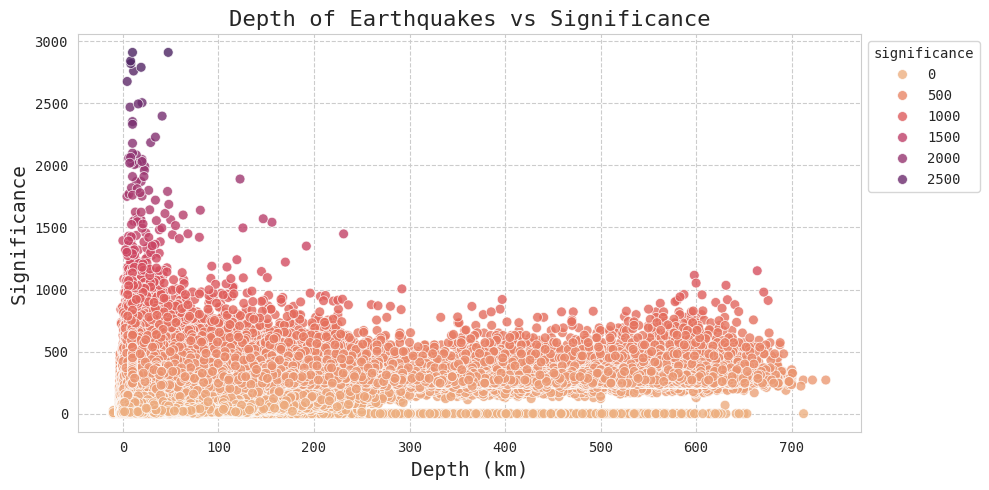

In [66]:
# Sets the style 
sns.set_style('whitegrid', {"grid.linestyle": "--", 'font.family': ["monospace"]})

# Creates the plot area
plt.figure(figsize=(10, 5))

# Plots as a scatter plot
ax = sns.scatterplot(data=df, y='significance', x='depth', hue='significance', palette='flare', alpha=0.8, s=50)

# Adds title and labels
ax.set_xlabel('Depth (km)', fontsize=14)
ax.set_ylabel('Significance', fontsize=14)
ax.set_title('Depth of Earthquakes vs Significance', fontsize=16)

# Makes sure the legend does not cover the plotted area
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
# Adjust layout to fit the plot and labels
plt.tight_layout()  
plt.show()

#### <font color='yellow'>Answer to Q3: In this plot, while the earthquakes with smaller significance (up to 1000) have various depth, the earthquakes with high significance (over 1000) seemed to have occurred close to the surface. The earthquakes that had higher impact seem to be related to the depth(shallowness) of the earthquakes. </font>

### Q4. What ranges of magnitudes are more likely to set the tsunami flag on?

In [67]:
# Get the number of earthquakes that turned on tsunami flags for each magnitude category
tsunami_magnitude = df[df['tsunami'] == 1].groupby('mag_category', observed=False).size()
tsunami_magnitude.head()

mag_category
2.5 or less      1
2.5 to 5.4     951
5.5 to 6.0     125
6.1 to 6.9     322
7.0 to 7.9     108
dtype: int64

In [68]:
# Get the total number of rows that fall into each magnitude category
total_magnitude = df.groupby('mag_category', observed=False).size()
total_magnitude.head()

mag_category
2.5 or less    2511999
2.5 to 5.4      729075
5.5 to 6.0       12135
6.1 to 6.9        3352
7.0 to 7.9         463
dtype: int64

In [69]:
# Calculate the proportion of the earthquakes that caused tsunami 
tsunami_proportion = tsunami_magnitude / total_magnitude

In [70]:
tsunami_proportion_df = tsunami_proportion.reset_index(name='proportion_of_tsunamis')
tsunami_proportion_df

,mag_category,proportion_of_tsunamis
0,2.5 or less,3.980893e-07
1,2.5 to 5.4,1.304393e-03
2,5.5 to 6.0,1.030078e-02
3,6.1 to 6.9,9.606205e-02
4,7.0 to 7.9,2.332613e-01
5,8.0 and above,2.727273e-01


<font color='yellow'>We can see that the proportion of tsunami flag is increasing as the magnitude increases. Yet, it is hard to see differences between each category.</font>

#### Plot the data

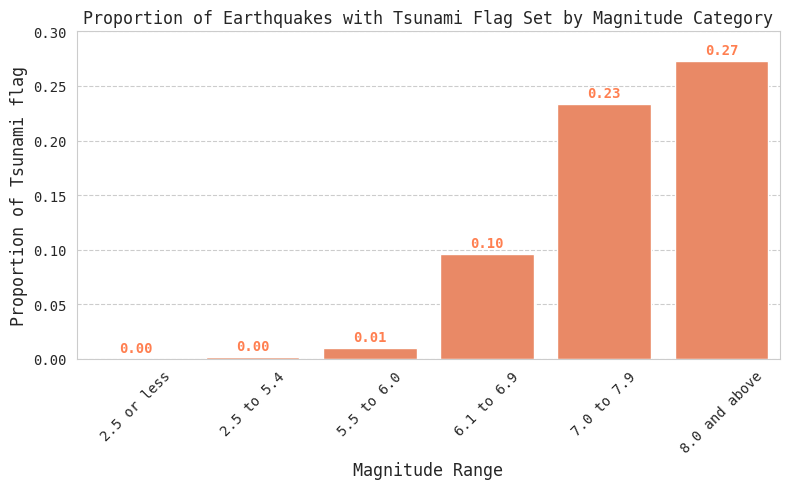

In [71]:
# Reset the index to create the dataframe from the tsunami_proportion series
tsunami_proportion_df = tsunami_proportion.reset_index(name='proportion_of_tsunamis')

# Set the style 
sns.set_style('whitegrid', {"grid.linestyle": "--", 'font.family': ["monospace"]})

# Sets the figure size using matplotlib
plt.figure(figsize=(8, 5))
# Plot the data using seaborn
ax = sns.barplot(data=tsunami_proportion_df, x='mag_category', y='proportion_of_tsunamis', color = 'coral')

# Add text labels above the bars
for index, row in tsunami_proportion_df.iterrows(): #Iterate over DataFrame rows as (index, Series) pairs.
    ax.text(
        row['mag_category'],  # x position (center of the bar)
        row['proportion_of_tsunamis'] + 0.01 ,  # y position (top of the bar)
        f"{row['proportion_of_tsunamis']:.2f}",  # Text label (formatted to 2 decimal places)
        color='coral',  # Text color
        fontweight = 'bold', # Bolded text
        ha='center',  # Horizontal alignment
        va='center'   # Vertical alignment
    )

# Add titles and labels
ax.set_title('Proportion of Earthquakes with Tsunami Flag Set by Magnitude Category', fontsize=12)
ax.set_xlabel('Magnitude Range', fontsize=12)
ax.set_ylabel('Proportion of Tsunami flag', fontsize=12)
ax.set_ylim(0.00, 0.30)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
# Rotate x-axis labels for better readability
ax.tick_params('x', labelrotation=45)

# Show the plot
plt.tight_layout() # Makes sure all elements are visible
plt.show()

#### <font color='yellow'>Answer to Q4: From this plot, I can see the higher the magnitude, the more likely the tsunami flag is set. Specifically, the magnitudes larger than 7.0 seem to cause the tsunami flag to be set more often. </font>

## Phase 5: Visualize the Data

### Q5. Which regions experience the large earthquakes?

### (1) 20 Largest Earthquakes

Get the 20 largest earthqueks data

In [72]:
top20_earthquakes = df.nlargest(20, 'magnitude')

#### Plot the data on the world map

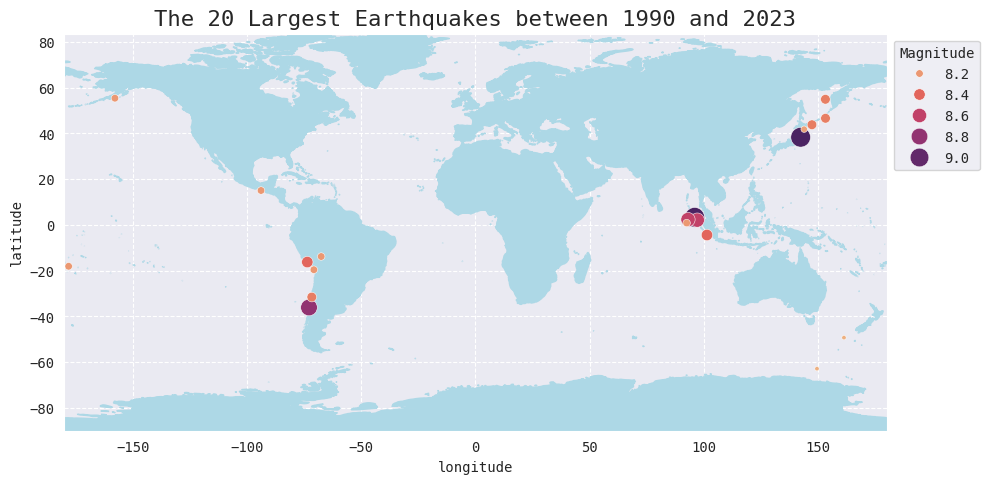

In [73]:
# Use 'darkgrid' to make the map easier to see
sns.set_style('darkgrid', {"grid.linestyle": "--", 'font.family': ["monospace"]})

# Create fig and ax 
fig, ax = plt.subplots(figsize=(10, 8))
# Reads the world map shapefile, then plot the world map in the plot area
world_map = geo.read_file('data/50m_cultural/ne_50m_admin_0_map_subunits.shp')
world_map.plot(ax=ax, color='lightblue', edgecolor='lightblue')
# Gets the bound of the world map
world_bounds = world_map.total_bounds

# Plot the longitude and latitude as scatter plot
ax = sns.scatterplot(data=top20_earthquakes, x='longitude', y='latitude', 
                     size='magnitude', sizes = (10, 200), hue='magnitude', palette='flare')

# Add the title and the legend
ax.set_title('The 20 Largest Earthquakes between 1990 and 2023', fontsize=16)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Magnitude', title_fontsize='10')

# Adjusts the limits of plot area based on the world map bounraries
ax.set_xlim(world_bounds[0], world_bounds[2])
ax.set_ylim(world_bounds[1], world_bounds[3])

# Show the plot
plt.tight_layout() 
plt.show()

<font color = 'yellow'>=>Large earthquakes are gathererd around South America, Japan and Indonesia.</font>

### (2) 100 largest earthquakes 

In [74]:
top100_earthquakes = df.nlargest(100, 'magnitude')

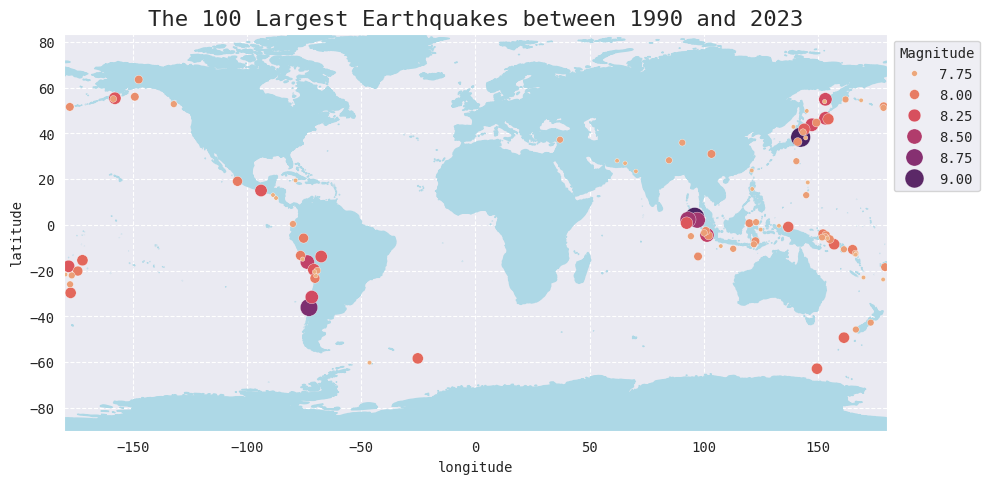

In [75]:
sns.set_style('darkgrid', {"grid.linestyle": "--", 'font.family': ["monospace"]})

fig, ax = plt.subplots(figsize=(10, 8))
world_map = geo.read_file('data/50m_cultural/ne_50m_admin_0_map_subunits.shp')
world_map.plot(ax=ax, color='lightblue', edgecolor='lightblue')
world_bounds = world_map.total_bounds

ax = sns.scatterplot(data=top100_earthquakes, x='longitude', y='latitude', 
                     size='magnitude', sizes = (10, 200), hue='magnitude', palette='flare')
ax.set_title('The 100 Largest Earthquakes between 1990 and 2023', fontsize=16)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Magnitude', title_fontsize='10')

ax.set_xlim(world_bounds[0], world_bounds[2])
ax.set_ylim(world_bounds[1], world_bounds[3])

plt.tight_layout() 
plt.show()

<font color = 'yellow'>=>This plot also shows the large earthquakes are mostly around South America, Japan and Indonesia.<br> But I also notice that some large dots are in Alaska, Mexico, Oceania as well.</font>

### (3) 500 largest earthquakes 

In [76]:
top500_earthquakes = df.nlargest(500, 'magnitude')

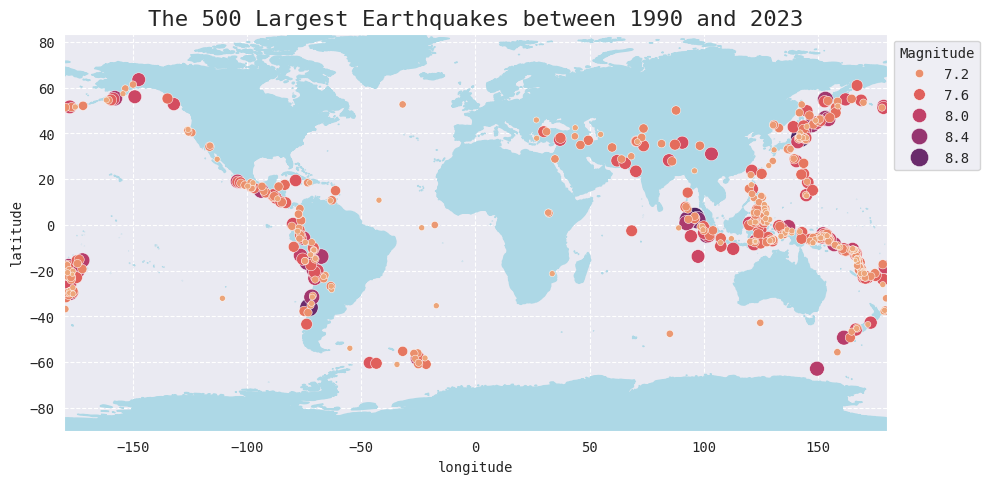

In [77]:
fig, ax = plt.subplots(figsize=(10, 8))
world_map = geo.read_file('data/50m_cultural/ne_50m_admin_0_map_subunits.shp')
world_map.plot(ax=ax, color='lightblue', edgecolor='lightblue')
world_bounds = world_map.total_bounds
ax = sns.scatterplot(data=top500_earthquakes, x='longitude', y='latitude', 
                     size='magnitude', sizes = (10, 200), hue='magnitude', palette='flare')

ax.set_xlim(world_bounds[0], world_bounds[2])
ax.set_ylim(world_bounds[1], world_bounds[3])
ax.set_title('The 500 Largest Earthquakes between 1990 and 2023', fontsize=16)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Magnitude', title_fontsize='10')

plt.tight_layout() 
plt.show()

#### <font color = 'yellow'>Answer to Q5: This plot shows more clearly what parts of the world have experienced large earthquakes. I can see most of the large earthquakes occurred in the area called 'Ring of Fire', which is a tectonic belt of volcanoes surrounding the Pacific Ocean. </font>

### Q6. Does the locations of earthquakes correspond to the borders of tectonic plates? 

**Tectonic plates** are large slabs of rock that divide Earth’s crust, move constantly to reshape the Earth’s landscape.  
(source: https://www.earthquakeauthority.com/blog/2020/understanding-plate-tectonic-theory)

### Adding tectonic plates map to the 500 largest earthquake plot

tectonic plates shapefile URL: https://github.com/fraxen/tectonicplates

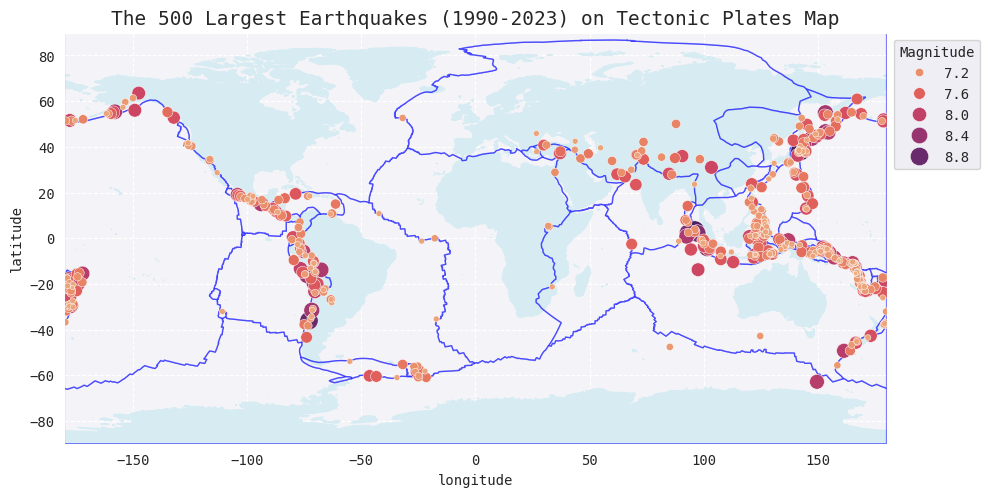

In [78]:
fig, ax = plt.subplots(figsize=(10, 8))
world_map = geo.read_file('data/50m_cultural/ne_50m_admin_0_map_subunits.shp')
world_map.plot(ax=ax, color='lightblue', edgecolor='lightblue')
# Reads the tectonic plate map shapefile, then plot the map in the plot area on top of the world map
plates = geo.read_file('data/tectonicplates-master/PB2002_plates.shp')
# Uses the alpha value for transparency to let the world map to be seen through 
plates.plot(ax=ax, color='white', edgecolor='blue', alpha=0.5)

# Gets the bounds of both GeoDataFrames
world_bounds = world_map.total_bounds
plates_bounds = plates.total_bounds

# Combines bounds to get the full extent
combined_bounds = [
    min(world_bounds[0], plates_bounds[0]),  # min x
    min(world_bounds[1], plates_bounds[1]),  # min y
    max(world_bounds[2], plates_bounds[2]),  # max x
    max(world_bounds[3], plates_bounds[3])   # max y
]

# Set the limits of the plot to fit the shapefiles
ax.set_xlim(combined_bounds[0], combined_bounds[2])
ax.set_ylim(combined_bounds[1], combined_bounds[3])

# plots the data as a scatter plot
ax = sns.scatterplot(data=top500_earthquakes, x='longitude', y='latitude', 
                     size='magnitude', sizes = (10, 200), hue='magnitude', palette='flare')

# Adds the title and the legend
ax.set_title('The 500 Largest Earthquakes (1990-2023) on Tectonic Plates Map', fontsize=14)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title='Magnitude', title_fontsize='10')

# Show the plot
plt.tight_layout() 
plt.show()

#### <font color = 'yellow'>Answer to Q6: Based on this plot, we can see that the large earthquakes are gathered along where tectonic plates meet, so we can say that the location of earthquakes correspond to the border of tectonic plates. </font>

## Summary of Questions and Answers

## Summary of Analysis